## Import Datas

In [ ]:
!pip install QuantLib

In [ ]:

import numpy as np
import QuantLib as ql

## Heston price

In [ ]:
ticker = "MSFT"
option_type="put"

In [ ]:
v0 = 0.04
kappa = 2.0
theta = 0.04
sigma = 0.3
rho = -0.7

In [ ]:


def heston_price(S, K, T, r, v0, kappa, theta, sigma, rho, option_type='call'):
    # Dates
    calendar = ql.NullCalendar()
    day_count = ql.Actual365Fixed()
    today = ql.Date.todaysDate()

    maturity_date = today + int(T * 365)

    # Processus
    spot = ql.QuoteHandle(ql.SimpleQuote(S))
    risk_free = ql.YieldTermStructureHandle(
        ql.FlatForward(today, r, day_count)
    )
    dividend = ql.YieldTermStructureHandle(
        ql.FlatForward(today, 0.0, day_count)
    )

    heston_process = ql.HestonProcess(
        risk_free, dividend, spot,
        v0, kappa, theta, sigma, rho
    )

    model = ql.HestonModel(heston_process)
    engine = ql.AnalyticHestonEngine(model)

    payoff = ql.PlainVanillaPayoff(
        ql.Option.Call if option_type == 'call' else ql.Option.Put,
        K
    )

    exercise = ql.EuropeanExercise(maturity_date)
    option = ql.VanillaOption(payoff, exercise)
    option.setPricingEngine(engine)

    return option.NPV()

In [ ]:
test_data['Heston_price'] = test_data.apply(
    lambda row: heston_price(
        S=row['sousJacent'],
        K=row['strike'],
        T=row['time-to-maturity'],
        r=row['riskFreeRate'],
        v0=v0,
        kappa=kappa, 
        theta=theta,
        sigma=sigma,
        rho=rho,
        option_type=row['type']
    ),
    axis=1
)

/tmp/ipykernel_8194/2133373838.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Heston_price'] = test_data.apply(


In [ ]:
rmse_heston = np.sqrt(mean_squared_error(test_data['lastPrice'], test_data['Heston_price']))
mae_heston = mean_absolute_error(test_data['lastPrice'], test_data['Heston_price'])
print(f"Heston -> RMSE: {rmse_heston:.3f} | MAE: {mae_heston:.3f}")

Heston -> RMSE: 9.192 | MAE: 5.440


<Axes: >

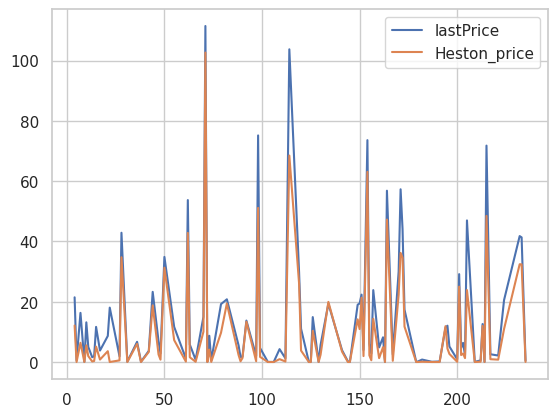

In [ ]:
test_data[["lastPrice", "Heston_price"]].head(100).plot()